In [3]:
import pandas as pd

# Load market data for each symbol (example with 7 symbols)
symbols = ['2yr', '3yr', '5yr', '7yr', '10yr', '20yr', '30yr']
market_data = {}
for symbol in symbols:
    market_data[symbol] = pd.read_csv(f'/content/{symbol}_combined_result.csv')

# Load trading data (with mixed symbols)
trading_data = pd.read_parquet('/content/merged_r8fin_trades.parquet')

In [4]:
trading_data

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,order_text,quote_or_hedge,hedge_target_price,cash_exchange_trade_id,timestamp,build_id,build_name,hide_duration,pop_ticks,label
0,2024-09-16,2024-09-13 07:15:38.351,NaT,2024-09-13 03:15:38.351,574483.0,550692610,7024116908,696111430.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
1,2024-09-16,2024-09-13 07:15:38.360,NaT,2024-09-13 03:15:38.360,574483.0,550692610,7024116908,696111431.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
2,2024-09-16,2024-09-13 07:15:39.964,NaT,2024-09-13 03:15:39.964,574483.0,550692629,7024116908,696111455.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
3,2024-09-16,2024-09-13 07:15:40.128,NaT,2024-09-13 03:15:40.128,574483.0,550692629,7024116908,696111456.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
4,2024-09-16,2024-09-13 07:15:39.963,NaT,2024-09-13 03:15:39.963,574483.0,550692627,7024116908,696111462.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5923554,2024-10-04,2024-10-04 20:59:06.135,2024-10-04 20:59:06.128,2024-10-04 16:59:06.128,590551.0,7029292600,7029291632,699617037.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 29@112.921875), -0.737...",Hedge,98.630859,5629609485429684499,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923555,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.130,2024-10-04 16:59:06.130,590551.0,7029292601,7029291632,699617036.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 57@112.921875), -0.737...",Hedge,98.630859,5629609485429684503,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923556,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.131,2024-10-04 16:59:06.131,590551.0,7029292601,7029291632,699617034.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 57@112.921875), -0.737...",Hedge,98.630859,5629609485429684505,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923557,2024-10-04,2024-10-04 20:59:06.138,2024-10-04 20:59:06.132,2024-10-04 16:59:06.132,590551.0,7029292602,7029291632,699617033.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 43@112.921875), -0.737...",Hedge,98.630859,5629609485429684507,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades


In [5]:
trading_data.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label'],
      dtype='object')

In [6]:
trading_data['destination'].notna().count()

5923559

In [7]:
trading_data['destination'].unique()

array(['sfe', 'cbot_2', 'cbot_3', 'cbot_1', 'cme_5', 'eurex_04',
       'eurex_09', 'eurex_06', 'eurex_07', 'eurex_08', 'eurex_05',
       'ifll_2', 'ice', 'cme_6', 'cme_4', 'ifll_1', 'ifll_0', 'ICEBERG',
       'SOR', 'TWAP', 'STP_PLUS', 'r8m.R8FINME', 'eurex', 'SOR_DWEB',
       'BTE_2'], dtype=object)

In [8]:
trading_data[['executiontime', 'recapid', 'orderid','parentcorrelationorderid', 'executionid', 'syntheticcontractidentifier','instrument']]

,executiontime,recapid,orderid,parentcorrelationorderid,executionid,syntheticcontractidentifier,instrument
0,2024-09-13 07:15:38.351,574483.0,550692610,7024116908,696111430.0,SC10091306372236346472,Z XM ROLL 1.8% FRONTS
1,2024-09-13 07:15:38.360,574483.0,550692610,7024116908,696111431.0,SC10091306372236346472,Z XM ROLL 1.8% FRONTS
2,2024-09-13 07:15:39.964,574483.0,550692629,7024116908,696111455.0,SC10091306372236346472,Z XM ROLL 1.8% FRONTS
3,2024-09-13 07:15:40.128,574483.0,550692629,7024116908,696111456.0,SC10091306372236346472,Z XM ROLL 1.8% FRONTS
4,2024-09-13 07:15:39.963,574483.0,550692627,7024116908,696111462.0,SC10091306372236346472,Z XM ROLL 1.8% FRONTS
...,...,...,...,...,...,...,...
5923554,2024-10-04 20:59:06.135,590551.0,7029292600,7029291632,699617037.0,SC10092522361807645197,CT5-TYZ4-CT10 (TYFLY) (Y)
5923555,2024-10-04 20:59:06.136,590551.0,7029292601,7029291632,699617036.0,SC10092522361807645197,CT5-TYZ4-CT10 (TYFLY) (Y)
5923556,2024-10-04 20:59:06.136,590551.0,7029292601,7029291632,699617034.0,SC10092522361807645197,CT5-TYZ4-CT10 (TYFLY) (Y)
5923557,2024-10-04 20:59:06.138,590551.0,7029292602,7029291632,699617033.0,SC10092522361807645197,CT5-TYZ4-CT10 (TYFLY) (Y)


In [9]:
len(trading_data)

5923559

In [10]:
trading_data['security_type'].unique()

array(['F', 'C'], dtype=object)

## select only cash type securities

In [11]:
cash_filter = trading_data[trading_data['security_type'] == 'C'].sort_values(by='parentcorrelationorderid')
cash_filter

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,order_text,quote_or_hedge,hedge_target_price,cash_exchange_trade_id,timestamp,build_id,build_name,hide_duration,pop_ticks,label
4458667,2024-08-05,2024-08-05 17:34:42.356,2024-08-05 17:34:42.351,2024-08-05 13:34:42.351,543614.0,7014628446,7014144399,688940344.0,JEWTQFYJ,VZVUOWCA,...,"Quote, 1,1,-1,100.8359375",Quote,NaN,1722670556443382|B,1.722879e+18,102863.0,New Build,0.0,"comp_0: 8.0, comp_1: 1.0, comp_2: 0.0, comp_3:...",r8fin_trades
4425183,2024-08-05,2024-08-05 06:13:57.103,2024-08-05 06:13:57.102,2024-08-05 02:13:57.102,542242.0,7014172986,7014144404,688507443.0,UZIZISKH,IPRLWHII,...,"Quote, 1,1,-1,102.267578125",Quote,NaN,1722670556425990|B,1.722838e+18,102424.0,New Build,250.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0, comp_3:...",r8fin_trades
4425236,2024-08-05,2024-08-05 06:14:47.475,2024-08-05 06:14:47.473,2024-08-05 02:14:47.473,542242.0,7014173383,7014144404,688507724.0,UZIZISKH,IPRLWHII,...,"Quote, 1,1,-1,102.265625",Quote,NaN,O:70659785:19940:4946,1.722838e+18,102424.0,New Build,250.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0, comp_3:...",r8fin_trades
4425235,2024-08-05,2024-08-05 06:14:45.116,2024-08-05 06:14:45.114,2024-08-05 02:14:45.114,542242.0,7014173360,7014144404,688507710.0,UZIZISKH,IPRLWHII,...,"Quote, 1,1,-1,102.265625",Quote,NaN,1722670556426022|B,1.722838e+18,102424.0,New Build,250.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0, comp_3:...",r8fin_trades
4425234,2024-08-05,2024-08-05 06:14:45.088,2024-08-05 06:14:45.085,2024-08-05 02:14:45.085,542242.0,7014173346,7014144404,688507711.0,UZIZISKH,IPRLWHII,...,"Quote, 1,1,-1,102.265625",Quote,NaN,1722670556426021|B,1.722838e+18,102424.0,New Build,250.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0, comp_3:...",r8fin_trades
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567088,2024-10-31,2024-10-31 20:58:29.856,2024-10-31 20:58:29.855,2024-10-31 16:58:29.855,608659.0,7035088190,7035088007,703911332.0,NPWJIPAH,LPSCOYBG,...,"Hedge (of UST 5_YEAR SLD 4@99.845703125), -0.2...",Hedge,96.291016,1729923534594130|B,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567087,2024-10-31,2024-10-31 20:58:29.850,2024-10-31 20:58:29.849,2024-10-31 16:58:29.849,608659.0,7035088185,7035088007,703911334.0,NPWJIPAH,LPSCOYBG,...,"Quote, 1,1,-1,99.845703125",Quote,NaN,1729923534594129|S,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567126,2024-10-31,2024-10-31 20:58:30.427,2024-10-31 20:58:30.425,2024-10-31 16:58:30.425,608659.0,7035088288,7035088007,703911351.0,NPWJIPAH,LPSCOYBG,...,"Quote, 1,1,-1,99.84765625",Quote,NaN,1729923534594140|S,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567211,2024-10-31,2024-10-31 20:59:13.396,2024-10-31 20:59:13.394,2024-10-31 16:59:13.394,608684.0,7035088736,7035088736,703911758.0,GVLRYWXG,LRHUYACL,...,,Other,NaN,1729923534594162|B,1.730408e+18,NaN,None,NaN,None,r8fin_trades


In [12]:
new_cash_filter = cash_filter[cash_filter['parentcorrelationorderid'] == 7035088007].sort_values(by='executiontime')
new_cash_filter

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,order_text,quote_or_hedge,hedge_target_price,cash_exchange_trade_id,timestamp,build_id,build_name,hide_duration,pop_ticks,label
567043,2024-10-31,2024-10-31 20:58:19.630,2024-10-31 20:58:19.628,2024-10-31 16:58:19.628,608659.0,7035088008,7035088007,703911316.0,NPWJIPAH,LPSCOYBG,...,"Quote, 1,1,-1,99.84765625",Quote,NaN,1729923534594119|S,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567042,2024-10-31,2024-10-31 20:58:19.632,2024-10-31 20:58:19.629,2024-10-31 16:58:19.629,608659.0,7035088008,7035088007,703911315.0,NPWJIPAH,LPSCOYBG,...,"Quote, 1,1,-1,99.84765625",Quote,NaN,5637209309818703527,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567040,2024-10-31,2024-10-31 20:58:19.634,2024-10-31 20:58:19.630,2024-10-31 16:58:19.630,608659.0,7035088008,7035088007,703911312.0,NPWJIPAH,LPSCOYBG,...,"Quote, 1,1,-1,99.84765625",Quote,NaN,A20243050PZ1R00,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567041,2024-10-31,2024-10-31 20:58:19.646,2024-10-31 20:58:19.632,2024-10-31 16:58:19.632,608659.0,7035088008,7035088007,703911314.0,NPWJIPAH,LPSCOYBG,...,"Quote, 1,1,-1,99.84765625",Quote,NaN,1729923534594120|S,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567044,2024-10-31,2024-10-31 20:58:19.648,2024-10-31 20:58:19.635,2024-10-31 16:58:19.635,608659.0,7035088022,7035088007,703911313.0,NPWJIPAH,LPSCOYBG,...,"Hedge (of UST 5_YEAR SLD 1@99.84765625), -0.28...",Hedge,96.291016,1729923534594121|B,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567087,2024-10-31,2024-10-31 20:58:29.850,2024-10-31 20:58:29.849,2024-10-31 16:58:29.849,608659.0,7035088185,7035088007,703911334.0,NPWJIPAH,LPSCOYBG,...,"Quote, 1,1,-1,99.845703125",Quote,NaN,1729923534594129|S,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567088,2024-10-31,2024-10-31 20:58:29.856,2024-10-31 20:58:29.855,2024-10-31 16:58:29.855,608659.0,7035088190,7035088007,703911332.0,NPWJIPAH,LPSCOYBG,...,"Hedge (of UST 5_YEAR SLD 4@99.845703125), -0.2...",Hedge,96.291016,1729923534594130|B,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567089,2024-10-31,2024-10-31 20:58:29.868,2024-10-31 20:58:29.863,2024-10-31 16:58:29.863,608659.0,7035088197,7035088007,703911330.0,NPWJIPAH,LPSCOYBG,...,"Quote, 1,1,-1,99.845703125",Quote,NaN,A20243050PZ2A00,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567090,2024-10-31,2024-10-31 20:58:29.868,2024-10-31 20:58:29.862,2024-10-31 16:58:29.862,608659.0,7035088197,7035088007,703911331.0,NPWJIPAH,LPSCOYBG,...,"Quote, 1,1,-1,99.845703125",Quote,NaN,1729923534594131|S,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades
567091,2024-10-31,2024-10-31 20:58:30.140,2024-10-31 20:58:30.138,2024-10-31 16:58:30.138,608659.0,7035088208,7035088007,703911329.0,NPWJIPAH,LPSCOYBG,...,"Hedge (of UST 5_YEAR SLD 1@99.845703125), -0.2...",Hedge,96.291016,1729923534594132|B,1.730408e+18,77676.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades


In [13]:
new_cash_filter['instrument'].unique()

array(['CT5-CT30 (Y)'], dtype=object)

In [14]:
new_cash_filter['recapid'].unique()

array([608659.])

In [15]:
new_cash_filter['symbol'].unique()

array(['5 Year', '30 Year'], dtype=object)

# recapid + orderid

In [16]:
import pandas as pd

# Group by 'recapid' and count unique 'parentcorrelationorderid' values for each 'recapid'
recapid_group = trading_data.groupby('recapid')['orderid'].nunique().reset_index()
# recapid_group = trading_data.groupby('parentcorrelationorderid')['recapid'].nunique().reset_index()
# Rename columns for clarity
recapid_group.columns = ['recapid', 'orderid_count']
# recapid_group.columns = ['unique_parentcorrelationorderid_count', 'recapid']
# Filter to find recapids that have more than one parentcorrelationorderid
inconsistent_recapid = recapid_group[recapid_group['orderid_count'] > 1]

# Print the result
if inconsistent_recapid.empty:
    print("All orderid correspond to a single parentcorrelationorderid.")
else:
    print("Some orderid correspond to multiple parentcorrelationorderids:")
    print(inconsistent_recapid.sort_values('orderid_count'))

Some orderid correspond to multiple parentcorrelationorderids:
        recapid  orderid_count
15497  557918.0              2
14883  557288.0              2
14887  557292.0              2
14888  557293.0              2
21110  563722.0              2
...         ...            ...
5266   547398.0           3561
30728  573865.0           4366
29848  572963.0           4727
37373  580735.0           4955
38085  581463.0           5067

[54969 rows x 2 columns]


In [17]:
import pandas as pd

# Group by 'recapid' and count unique 'parentcorrelationorderid' values for each 'recapid'
recapid_group = trading_data.groupby('parentcorrelationorderid')['orderid'].nunique().reset_index()
# recapid_group = trading_data.groupby('parentcorrelationorderid')['recapid'].nunique().reset_index()
# Rename columns for clarity
recapid_group.columns = ['unique_parentcorrelationorderid_count', 'orderid']
# recapid_group.columns = ['unique_parentcorrelationorderid_count', 'recapid']
# Filter to find recapids that have more than one parentcorrelationorderid
inconsistent_recapid = recapid_group[recapid_group['unique_parentcorrelationorderid_count'] > 1]

# Print the result
if inconsistent_recapid.empty:
    print("All orderid correspond to a single parentcorrelationorderid.")
else:
    print("Some orderid correspond to multiple parentcorrelationorderids:")
    print(inconsistent_recapid.sort_values('unique_parentcorrelationorderid_count'))

Some orderid correspond to multiple parentcorrelationorderids:
       unique_parentcorrelationorderid_count  orderid
0                                  515362992        1
1                                  515382999        1
2                                  515383000        1
3                                  515383007        1
4                                  515388861        1
...                                      ...      ...
67353                             7035086854        4
67354                             7035088000       24
67355                             7035088007       12
67356                             7035088736        1
67357                             7035089079        1

[67358 rows x 2 columns]


In [18]:
inconsistent_recapid.max()

,0
unique_parentcorrelationorderid_count,7035089079
orderid,5067


## First we tried recapID, but found that there were multiple parentcorrelationorderid’s associated with the same recapID. For example, last recapID has 25 parent orders it is associated with


In [19]:
import pandas as pd

# Group by 'recapid' and count unique 'parentcorrelationorderid' values for each 'recapid'
recapid_group = cash_filter.groupby('recapid')['parentcorrelationorderid'].nunique().reset_index()
# recapid_group = trading_data.groupby('parentcorrelationorderid')['recapid'].nunique().reset_index()
# Rename columns for clarity
recapid_group.columns = ['recapid', 'unique_parentcorrelationorderid_count']
# recapid_group.columns = ['unique_parentcorrelationorderid_count', 'recapid']
# Filter to find recapids that have more than one parentcorrelationorderid
inconsistent_recapid = recapid_group[recapid_group['unique_parentcorrelationorderid_count'] > 1]

# Print the result
if inconsistent_recapid.empty:
    print("All recapids correspond to a single parentcorrelationorderid.")
else:
    print("Some recapids correspond to multiple parentcorrelationorderids:")
    print(inconsistent_recapid.sort_values('unique_parentcorrelationorderid_count'))


Some recapids correspond to multiple parentcorrelationorderids:
        recapid  unique_parentcorrelationorderid_count
14     542039.0                                      2
26627  581977.0                                      2
26750  582130.0                                      2
26804  582197.0                                      2
26866  582280.0                                      2
...         ...                                    ...
573    542973.0                                      8
42710  605950.0                                      9
26930  582425.0                                     10
8626   554044.0                                     11
28484  584773.0                                     12

[828 rows x 2 columns]


## Then we tried parentcorrelationorderid and that also has multiple recapIDs associated with it as well

In [24]:
# Group by 'parentcorrelationorderid' and count unique 'recapid' values for each 'parentcorrelationorderid'
parentcorrelation_group = cash_filter.groupby('parentcorrelationorderid')['recapid'].nunique().reset_index()

# Rename columns for clarity
parentcorrelation_group.columns = ['parentcorrelationorderid', 'unique_recapid_count']

# Filter to find parentcorrelationorderids that have more than one unique recapid
inconsistent_parentcorrelation = parentcorrelation_group[parentcorrelation_group['unique_recapid_count'] > 1]

# Print the result
if inconsistent_parentcorrelation.empty:
    print("All parentcorrelationorderids correspond to a single recapid.")
else:
    print("Some parentcorrelationorderids correspond to multiple recapids:")
    print(inconsistent_parentcorrelation.sort_values('unique_recapid_count'))


Some parentcorrelationorderids correspond to multiple recapids:
       parentcorrelationorderid  unique_recapid_count
742                  7014464889                     2
34184                7029752774                     2
34175                7029750142                     2
32759                7029092061                     2
31819                7028661793                     2
...                         ...                   ...
17346                7022150185                     2
44034                7034382050                     2
19086                7022880198                     3
25168                7025673236                     3
15798                7021446247                     3

[84 rows x 2 columns]


# orderid and execution id are not the metaorder identifiers

In [35]:
# select one recapid == 584773.0
filtered_data = cash_filter[cash_filter['recapid'] == 584773.0].sort_values(by='executiontime')

# Select relevant columns
filtered_data = filtered_data[['executiontime','executionid','instrument', 'recapid', 'orderid','parentcorrelationorderid', 'security_type', 'quantity', 'side', 'quote_or_hedge']]

# Display the filtered and sorted data
print(filtered_data)

                  executiontime  executionid instrument   recapid     orderid  \
2815957 2024-09-27 15:50:04.410  698411514.0   CT7-TYZ4  584773.0  7027473168   
2815958 2024-09-27 15:50:04.414  698411515.0   CT7-TYZ4  584773.0  7027473169   
2815959 2024-09-27 15:50:04.416  698411497.0   CT7-TYZ4  584773.0  7027473170   
2815960 2024-09-27 15:50:04.416  698411499.0   CT7-TYZ4  584773.0  7027473171   
2815961 2024-09-27 15:50:04.418  698411500.0   CT7-TYZ4  584773.0  7027473172   
2815962 2024-09-27 15:50:04.420  698411501.0   CT7-TYZ4  584773.0  7027473173   
2815963 2024-09-27 15:50:04.422  698411502.0   CT7-TYZ4  584773.0  7027473174   
2815964 2024-09-27 15:50:04.424  698411503.0   CT7-TYZ4  584773.0  7027473176   
2815965 2024-09-27 15:50:04.426  698411504.0   CT7-TYZ4  584773.0  7027473177   
2815966 2024-09-27 15:50:04.430  698411506.0   CT7-TYZ4  584773.0  7027473192   
2815967 2024-09-27 15:50:04.430  698411508.0   CT7-TYZ4  584773.0  7027473199   
2815968 2024-09-27 15:50:04.

In [36]:
filtered_data['parentcorrelationorderid'].unique()

array([7027280679, 7027280680, 7027280681, 7027280682, 7027280683,
       7027280684, 7027280685, 7027280686, 7027280687, 7027280688,
       7027280689, 7027280690])

In [ ]:
# select one parentcorrelationorderid with 0 unique_instrument_count
filtered_data = cash_filter[cash_filter['recapid'] == 584773.0].sort_values(by='executiontime')

# Select relevant columns
filtered_data = filtered_data[['executiontime','executionid','instrument', 'recapid', 'orderid','parentcorrelationorderid', 'security_type', 'quantity', 'side', 'quote_or_hedge', 'exchange', 'destination', 'client' , 'order_text']]

# Display the filtered and sorted data
print(filtered_data.head(20))

In [33]:
# select one parentcorrelationorderid with 0 unique_instrument_count
filtered_data = cash_filter[cash_filter['recapid'] == 605950.0].sort_values(by='executiontime')
# Select relevant columns
filtered_data = filtered_data[['executiontime','executionid','instrument', 'recapid', 'orderid','parentcorrelationorderid', 'security_type', 'quantity', 'side', 'quote_or_hedge']]

# Display the filtered and sorted data
print(filtered_data.head(20))

                  executiontime  executionid instrument   recapid     orderid  \
2727546 2024-10-29 19:34:45.888  703211678.0   CT7-TYZ4  605950.0  7034198428   
2727547 2024-10-29 19:34:45.888  703211678.0   CT7-TYZ4  605950.0  7034198428   
2727597 2024-10-29 19:35:39.899  703211732.0   CT7-TYZ4  605950.0  7034198731   
2727598 2024-10-29 19:35:39.899  703211732.0   CT7-TYZ4  605950.0  7034198731   
2727601 2024-10-29 19:35:39.949  703211730.0   CT7-TYZ4  605950.0  7034198747   
2727602 2024-10-29 19:35:39.949  703211730.0   CT7-TYZ4  605950.0  7034198747   
2727604 2024-10-29 19:35:39.955  703211731.0   CT7-TYZ4  605950.0  7034198747   
2727603 2024-10-29 19:35:39.955  703211731.0   CT7-TYZ4  605950.0  7034198747   
2727606 2024-10-29 19:35:39.969  703211729.0   CT7-TYZ4  605950.0  7034198763   
2727605 2024-10-29 19:35:39.969  703211729.0   CT7-TYZ4  605950.0  7034198763   
2727609 2024-10-29 19:35:39.983  703211728.0   CT7-TYZ4  605950.0  7034198769   
2727608 2024-10-29 19:35:39.

In [34]:
filtered_data['parentcorrelationorderid'].unique()

array([7034198283, 7034200701, 7034201008, 7034203992, 7034205275,
       7034207794, 7034209199, 7034210325, 7034211089])

In [39]:
filtered_data['parentcorrelationorderid'].max()

7027280690

In [ ]:
len(filtered_data)

320

In [ ]:
# select one parentcorrelationorderid with 0 unique_instrument_count
filtered_data = cash_filter[cash_filter['parentcorrelationorderid'] == 7034198283.0].sort_values(by='executiontime')
# Select relevant columns
filtered_data = filtered_data[['executiontime','executionid','instrument', 'recapid', 'orderid','parentcorrelationorderid', 'security_type', 'quantity', 'side', 'quote_or_hedge', 'exchange', 'destination', 'client' , 'order_text']]

# Display the filtered and sorted data
print(filtered_data.head(20))

filtered_data.to_csv('filtered_data_one_parentcorrelationorderid')

                  executiontime  executionid instrument   recapid     orderid  \
2727547 2024-10-29 19:34:45.888  703211678.0   CT7-TYZ4  605950.0  7034198428   
2727546 2024-10-29 19:34:45.888  703211678.0   CT7-TYZ4  605950.0  7034198428   
2727597 2024-10-29 19:35:39.899  703211732.0   CT7-TYZ4  605950.0  7034198731   
2727598 2024-10-29 19:35:39.899  703211732.0   CT7-TYZ4  605950.0  7034198731   
2727601 2024-10-29 19:35:39.949  703211730.0   CT7-TYZ4  605950.0  7034198747   
2727602 2024-10-29 19:35:39.949  703211730.0   CT7-TYZ4  605950.0  7034198747   
2727604 2024-10-29 19:35:39.955  703211731.0   CT7-TYZ4  605950.0  7034198747   
2727603 2024-10-29 19:35:39.955  703211731.0   CT7-TYZ4  605950.0  7034198747   
2727606 2024-10-29 19:35:39.969  703211729.0   CT7-TYZ4  605950.0  7034198763   
2727605 2024-10-29 19:35:39.969  703211729.0   CT7-TYZ4  605950.0  7034198763   
2727608 2024-10-29 19:35:39.983  703211726.0   CT7-TYZ4  605950.0  7034198769   
2727609 2024-10-29 19:35:39.

In [ ]:
len(filtered_data)

80

In [ ]:
import pandas as pd

# Group by 'recapid' and count unique 'parentcorrelationorderid' values for each 'recapid'
recapid_group = trading_data.groupby('recapid')['parentcorrelationorderid'].nunique().reset_index()
# recapid_group = trading_data.groupby('parentcorrelationorderid')['recapid'].nunique().reset_index()
# Rename columns for clarity
recapid_group.columns = ['recapid', 'unique_parentcorrelationorderid_count']
# recapid_group.columns = ['unique_parentcorrelationorderid_count', 'recapid']
# Filter to find recapids that have more than one parentcorrelationorderid
inconsistent_recapid = recapid_group[recapid_group['unique_parentcorrelationorderid_count'] > 1]

# Print the result
if inconsistent_recapid.empty:
    print("All recapids correspond to a single parentcorrelationorderid.")
else:
    print("Some recapids correspond to multiple parentcorrelationorderids:")
    print(inconsistent_recapid.sort_values('unique_parentcorrelationorderid_count'))

In [ ]:
inconsistent_recapid.max()

,0
recapid,608651.0
unique_parentcorrelationorderid_count,25.0


In [ ]:
len(trading_data)

5923559

In [ ]:
len(trading_data['executionid'].unique())

5768753

In [ ]:
import pandas as pd

# Group by 'orderid' and count the number of unique 'executionid' values for each 'orderid'
orderid_execution_count = trading_data.groupby('orderid')['executionid'].nunique().reset_index()

# Rename columns for better understanding
orderid_execution_count.columns = ['orderid', 'unique_executionid_count']

# Display the resulting DataFrame
print(orderid_execution_count)

# Optionally, filter to find any orderid with more than one associated executionid
multiple_executions = orderid_execution_count[orderid_execution_count['unique_executionid_count'] > 1]

# Print the orders with multiple executions
print("\nOrder IDs with multiple associated execution IDs:")
print(multiple_executions)

            orderid  unique_executionid_count
0         515382999                        20
1         515383000                         6
2         515383007                        50
3         515383017                         1
4         515383018                         1
...             ...                       ...
3292507  7035089079                         1
3292508  7035089092                         1
3292509  7035089116                         2
3292510  7035089136                         2
3292511  7035089145                         1

[3292512 rows x 2 columns]

Order IDs with multiple associated execution IDs:
            orderid  unique_executionid_count
0         515382999                        20
1         515383000                         6
2         515383007                        50
88        515383238                         2
89        515383242                         2
...             ...                       ...
3292495  7035088887                         2
3

In [ ]:
orderid_execution_count.max()

,0
orderid,7035089145
unique_executionid_count,2434


In [ ]:
# Group by 'recapid' and 'parentcorrelationorderid', then count unique 'instrument' values
recapid_group = trading_data.groupby(['recapid'])['instrument'].nunique().reset_index()

# Rename columns for clarity
recapid_group.columns = ['recapid', 'unique_instrument_count']

# Print the result
print(recapid_group)

        recapid  unique_instrument_count
0      540807.0                        1
1      540887.0                        1
2      541144.0                        1
3      541170.0                        1
4      541395.0                        1
...         ...                      ...
64300  608700.0                        1
64301  608701.0                        1
64302  608702.0                        1
64303  608703.0                        1
64304  608705.0                        1

[64305 rows x 2 columns]


In [ ]:
recapid_group['unique_instrument_count'].unique()

array([1])

In [ ]:
# Group by 'recapid' and 'parentcorrelationorderid', then count unique 'instrument' values
recapid_group = trading_data.groupby(['parentcorrelationorderid'])['instrument'].nunique().reset_index()

# Rename columns for clarity
recapid_group.columns = ['parentcorrelationorderid', 'unique_instrument_count']

# Print the result
print(recapid_group)

       parentcorrelationorderid  unique_instrument_count
0                     515362992                        1
1                     515382999                        1
2                     515383000                        1
3                     515383007                        1
4                     515388861                        1
...                         ...                      ...
67353                7035086854                        1
67354                7035088000                        1
67355                7035088007                        1
67356                7035088736                        1
67357                7035089079                        1

[67358 rows x 2 columns]


In [ ]:
recapid_group[recapid_group['unique_instrument_count'] == 3]

,parentcorrelationorderid,unique_instrument_count
11132,5008358120,3
11133,5008358121,3


In [ ]:
# select one parentcorrelationorderid with 0 unique_instrument_count
filtered_data = trading_data[trading_data['parentcorrelationorderid'] == 3002045100].sort_values(by='executiontime')

# Select relevant columns
filtered_data = filtered_data[['executiontime','executionid','instrument', 'recapid', 'orderid', 'security_type', 'quantity', 'side', 'quote_or_hedge', 'exchange', 'destination']]

# Display the filtered and sorted data
print(filtered_data.head(20))

filtered_data.to_csv('filtered_data_one_parentcorrelationorderid')

       executiontime  executionid instrument  recapid     orderid  \
615537           NaT          NaN       None      NaN  3002045132   
615538           NaT          NaN       None      NaN  3002045132   
615539           NaT          NaN       None      NaN  3002045129   
615540           NaT          NaN       None      NaN  3002045129   
615541           NaT          NaN       None      NaN  3002045131   
615583           NaT          NaN       None      NaN  3002045131   

       security_type  quantity side quote_or_hedge exchange destination  
615537             F       6.0    S          Hedge    EUREX    eurex_05  
615538             F       3.0    S          Hedge    EUREX    eurex_05  
615539             F       1.0    S          Other    EUREX    eurex_06  
615540             F       3.0    S          Other    EUREX    eurex_06  
615541             F       6.0    B          Hedge    EUREX    eurex_07  
615583             F       5.0    B          Hedge    EUREX    eurex_07 

In [ ]:
#5008358120
# select one parentcorrelationorderid with 0 unique_instrument_count
filtered_data = trading_data[trading_data['parentcorrelationorderid'] == 5008358120].sort_values(by='executiontime')

# Select relevant columns
filtered_data = filtered_data[['executiontime','executionid','instrument', 'recapid', 'orderid', 'security_type', 'quantity', 'side', 'quote_or_hedge', 'exchange', 'destination']]

# Display the filtered and sorted data
print(filtered_data.head(20))

filtered_data.to_csv('filtered_data_one_parentcorrelationorderid')

        executiontime  executionid  \
661127            NaT          NaN   
661128            NaT          NaN   
914070            NaT          NaN   
914072            NaT          NaN   
1540667           NaT          NaN   
1540668           NaT          NaN   
1853977           NaT          NaN   
1853981           NaT          NaN   
5001898           NaT          NaN   
5001901           NaT          NaN   
5309334           NaT          NaN   
5309337           NaT          NaN   
5410130           NaT          NaN   
5410131           NaT          NaN   
5601939           NaT          NaN   
5601940           NaT          NaN   

                                           instrument   recapid     orderid  \
661127                                 CME SERU4-FFU4  556631.0  5008358120   
661128                                 CME SERU4-FFU4  556631.0  5008358120   
914070                  CME SERU4-FFU4,CME SERV4-FFV4  558915.0  5008358120   
914072                  CME SERU4-FFU

# with only cash `cash_filter`

In [ ]:
# Group by 'recapid' and 'parentcorrelationorderid', then count unique 'instrument' values
recapid_group = cash_filter.groupby(['recapid'])['instrument'].nunique().reset_index()

# Rename columns for clarity
recapid_group.columns = ['recapid', 'unique_instrument_count']

# Print the result
print(recapid_group)

        recapid  unique_instrument_count
0      542008.0                        1
1      542009.0                        1
2      542010.0                        1
3      542012.0                        1
4      542013.0                        1
...         ...                      ...
44517  608698.0                        1
44518  608699.0                        1
44519  608700.0                        1
44520  608702.0                        1
44521  608705.0                        1

[44522 rows x 2 columns]


In [ ]:
recapid_group['unique_instrument_count'].unique()

array([1])

In [ ]:
# Group by 'recapid' and 'parentcorrelationorderid', then count unique 'instrument' values
recapid_group = cash_filter.groupby(['parentcorrelationorderid'])['instrument'].nunique().reset_index()

# Rename columns for clarity
recapid_group.columns = ['parentcorrelationorderid', 'unique_instrument_count']

# Print the result
print(recapid_group)

       parentcorrelationorderid  unique_instrument_count
0                    7014144399                        1
1                    7014144404                        1
2                    7014144416                        1
3                    7014144417                        1
4                    7014144433                        1
...                         ...                      ...
45466                7035086854                        1
45467                7035088000                        1
45468                7035088007                        1
45469                7035088736                        1
45470                7035089079                        1

[45471 rows x 2 columns]


In [ ]:
recapid_group['unique_instrument_count'].unique()

array([1, 2])

In [ ]:
recapid_group[recapid_group['unique_instrument_count'] == 2]

,parentcorrelationorderid,unique_instrument_count
35874,7030598143,2
35877,7030599003,2
42999,7033811407,2


# this is correct

In [ ]:
hedge_data = trading_data[trading_data['quote_or_hedge'] == 'Hedge']


,instrument
5923478,CT5-TYZ4-CT10 (TYFLY) (Y)
5923482,CT5-TYZ4-CT10 (TYFLY) (Y)
5923484,CT3-CT5-CT10 (Y)
5923485,CT3-CT5-CT10 (Y)
5923487,CT3-CT5-CT10 (Y)
5923489,CT3-CT5-CT10 (Y)
5923492,CT2-CT30 (Y)
5923494,CT3-CT5-CT10 (Y)
5923495,CT3-CT5-CT10 (Y)
5923498,CT3-CT5-CT10 (Y)


In [ ]:
# select one parentcorrelationorderid with 0 unique_instrument_count
filtered_data = cash_filter[cash_filter['parentcorrelationorderid'] == 7030598143].sort_values(by='executiontime')
#filtered_data = filtered_data[filtered_data['recapid'] == 594797.0].sort_values(by='executiontime')
# Select relevant columns

filtered_data = filtered_data[['executiontime','executionid','instrument', 'recapid', 'orderid', 'security_type', 'quantity', 'side', 'quote_or_hedge', 'exchange', 'destination', 'syntheticcontractdefinition', 'exchange_lp']]

# Display the filtered and sorted data
print(filtered_data.head(20))

filtered_data.to_csv('filtered_data_one_parentcorrelationorderid')

                  executiontime  executionid                   instrument  \
2466497 2024-10-10 15:44:31.968  700482265.0                CT10-CT30 (Y)   
2466498 2024-10-10 15:44:31.978  700482269.0  CT10-CT30 (Y),CT20-CT30 (Y)   
2466499 2024-10-10 15:44:31.988  700482268.0                CT10-CT30 (Y)   
2466500 2024-10-10 15:44:31.990  700482267.0  CT10-CT30 (Y),CT20-CT30 (Y)   
2466501 2024-10-10 15:44:31.994  700482259.0                CT10-CT30 (Y)   
2466502 2024-10-10 15:44:31.998  700482258.0  CT10-CT30 (Y),CT20-CT30 (Y)   
2466503 2024-10-10 15:44:32.004  700482260.0                CT10-CT30 (Y)   
2466504 2024-10-10 15:44:32.008  700482256.0  CT10-CT30 (Y),CT20-CT30 (Y)   
2466505 2024-10-10 15:44:32.016  700482257.0                CT10-CT30 (Y)   
2466506 2024-10-10 15:44:32.020  700482262.0  CT10-CT30 (Y),CT20-CT30 (Y)   
2466508 2024-10-10 15:44:32.026  700482264.0                CT10-CT30 (Y)   
2466507 2024-10-10 15:44:33.715  700482263.0  CT10-CT30 (Y),CT20-CT30 (Y)   

In [ ]:
# select one parentcorrelationorderid with 0 unique_instrument_count
filtered_data = cash_filter[cash_filter['parentcorrelationorderid'] == 7030598143].sort_values(by='executiontime')
filtered_data = filtered_data[filtered_data['recapid'] == 594797.0].sort_values(by='executiontime')
# Select relevant columns

filtered_data = filtered_data[['executiontime','executionid','instrument', 'recapid', 'orderid', 'security_type', 'quantity', 'side', 'quote_or_hedge', 'exchange', 'destination', 'syntheticcontractdefinition', 'exchange_lp']]

# Display the filtered and sorted data
print(filtered_data.head(20))

filtered_data.to_csv('filtered_data_one_parentcorrelationorderid')

                  executiontime  executionid     instrument   recapid  \
2466497 2024-10-10 15:44:31.968  700482265.0  CT10-CT30 (Y)  594797.0   
2466499 2024-10-10 15:44:31.988  700482268.0  CT10-CT30 (Y)  594797.0   
2466501 2024-10-10 15:44:31.994  700482259.0  CT10-CT30 (Y)  594797.0   
2466503 2024-10-10 15:44:32.004  700482260.0  CT10-CT30 (Y)  594797.0   
2466505 2024-10-10 15:44:32.016  700482257.0  CT10-CT30 (Y)  594797.0   
2466508 2024-10-10 15:44:32.026  700482264.0  CT10-CT30 (Y)  594797.0   

            orderid security_type  quantity side quote_or_hedge exchange  \
2466497  7030598144             C       1.0    B          Quote      R8M   
2466499  7030598153             C       1.0    B          Quote      R8M   
2466501  7030598164             C       1.0    B          Quote      R8M   
2466503  7030598175             C       1.0    B          Quote     DWEB   
2466505  7030598190             C       1.0    B          Quote      R8M   
2466508  7030598200             

In [ ]:
# Correct the sorting operation to use `sort_values()`
filtered_data = trading_data[trading_data['recapid'] == 608651.0].sort_values(by='executiontime')

# Select relevant columns
filtered_data = filtered_data[['executiontime','executionid','instrument', 'recapid', 'orderid', 'security_type', 'quantity', 'side', 'quote_or_hedge', 'exchange', 'destination']]

# Display the filtered and sorted data
print(filtered_data.head(20))

filtered_data.to_csv('filtered_data_one_parentcorrelationorderid')

                 executiontime  executionid    instrument   recapid  \
562298 2024-10-31 20:30:41.682  703901223.0  CT7-CT10 (Y)  608651.0   
562297 2024-10-31 20:30:41.684  703901222.0  CT7-CT10 (Y)  608651.0   
562299 2024-10-31 20:30:41.694  703901220.0  CT7-CT10 (Y)  608651.0   
562300 2024-10-31 20:30:41.694  703901221.0  CT7-CT10 (Y)  608651.0   
562301 2024-10-31 20:30:41.696  703901225.0  CT7-CT10 (Y)  608651.0   
562734 2024-10-31 20:34:44.317  703902138.0  CT7-CT10 (Y)  608651.0   
562735 2024-10-31 20:34:48.773  703902140.0  CT7-CT10 (Y)  608651.0   
562845 2024-10-31 20:35:44.345  703902373.0  CT7-CT10 (Y)  608651.0   
562847 2024-10-31 20:35:44.351  703902366.0  CT7-CT10 (Y)  608651.0   
562846 2024-10-31 20:35:44.351  703902365.0  CT7-CT10 (Y)  608651.0   
562856 2024-10-31 20:35:45.089  703902378.0  CT7-CT10 (Y)  608651.0   
562857 2024-10-31 20:35:45.121  703902377.0  CT7-CT10 (Y)  608651.0   
562889 2024-10-31 20:36:03.233  703902438.0  CT7-CT10 (Y)  608651.0   
562890

In [ ]:
# Correct the sorting operation to use `sort_values()`
filtered_data = trading_data[trading_data['parentcorrelationorderid'] == 515490492].sort_values(by='executiontime')

# Select relevant columns
filtered_data = filtered_data[['executiontime','executionid','instrument', 'recapid', 'orderid', 'security_type', 'quantity', 'side', 'quote_or_hedge', 'exchange', 'destination']]

# Display the filtered and sorted data
print(filtered_data.head(20))

filtered_data.to_csv('filtered_data_one_parentcorrelationorderid')

                  executiontime  executionid               instrument  \
3163736 2024-08-06 13:15:39.940  689149896.0  IFLL SFI: FFLY U6-U7-U8   
3163735 2024-08-06 13:15:39.940  689149895.0  IFLL SFI: FFLY U6-U7-U8   
3163734 2024-08-06 13:15:39.940  689149893.0  IFLL SFI: FFLY U6-U7-U8   
3136430 2024-08-06 14:40:33.143  689208280.0  IFLL SFI: FFLY U6-U7-U8   
3136431 2024-08-06 14:40:33.143  689208281.0  IFLL SFI: FFLY U6-U7-U8   
3136432 2024-08-06 14:40:33.143  689208287.0  IFLL SFI: FFLY U6-U7-U8   
3150224 2024-08-06 15:45:27.365  689257591.0  IFLL SFI: FFLY U6-U7-U8   
3150223 2024-08-06 15:45:27.365  689257589.0  IFLL SFI: FFLY U6-U7-U8   
3150225 2024-08-06 15:45:27.365  689257592.0  IFLL SFI: FFLY U6-U7-U8   
3144407 2024-08-06 15:49:33.320  689257966.0  IFLL SFI: FFLY U6-U7-U8   
3144408 2024-08-06 15:49:33.320  689257974.0  IFLL SFI: FFLY U6-U7-U8   
3150260 2024-08-06 15:49:33.320  689257973.0  IFLL SFI: FFLY U6-U7-U8   
3150259 2024-08-06 15:49:33.320  689257970.0  IFLL 

In [ ]:
filtered_data['syntheticcontractidentifier'].unique()

array([None], dtype=object)

In [ ]:
filtered_data['exchange'].unique()

array(['IFLL'], dtype=object)

In [ ]:
filtered_data['quote_or_hedge'].unique()

array(['Other'], dtype=object)

In [ ]:
filtered_data['security_type'].unique()

array(['F'], dtype=object)

In [ ]:
filtered_data['instrument'].unique()

array(['IFLL SFI: FFLY U6-U7-U8'], dtype=object)

In [ ]:
filtered_data['recapid'].unique()

array([544844., 545323.])

# group by recapid

check whether the parient id and recapid are match

In [ ]:
len(trading_data['recapid'].unique())

64306

In [ ]:
len(trading_data['parentcorrelationorderid'].unique())

67358

In [ ]:
import pandas as pd

# Assuming trading_data is the DataFrame that contains 'recapid' column

# Correct way to sort by the 'recapid' column
trading_data_sorted = trading_data.sort_values(by='recapid')

# Optionally, reset the index after sorting
trading_data_sorted.reset_index(drop=True, inplace=True)

# Display the sorted DataFrame
print(trading_data_sorted.head())

  trade_date           executiontime brokerexecutiontime  \
0 2024-08-05 2024-08-02 11:56:39.570                 NaT   
1 2024-08-05 2024-08-02 12:03:44.767                 NaT   
2 2024-08-05 2024-08-02 12:03:44.831                 NaT   
3 2024-08-05 2024-08-02 12:03:32.794                 NaT   
4 2024-08-05 2024-08-02 12:03:34.358                 NaT   

             exec_time_et   recapid    orderid  parentcorrelationorderid  \
0 2024-08-02 07:56:39.570  540807.0  550658889                7013622778   
1 2024-08-02 08:03:44.767  540807.0  550658925                7013622778   
2 2024-08-02 08:03:44.831  540807.0  550658925                7013622778   
3 2024-08-02 08:03:32.794  540807.0  550658907                7013622778   
4 2024-08-02 08:03:34.358  540807.0  550658916                7013622778   

   executionid      firm    client  ... order_text quote_or_hedge  \
0  688104409.0  ZUMLOTRS  SVTLZESG  ...       None          Other   
1  688106333.0  ZUMLOTRS  SVTLZESG  ...     

In [ ]:
import pandas as pd

# Assuming 'trading_data' is your dataframe containing 'recapid' and 'parentcorrelationorderid'

# Step 1: Group by 'parentcorrelationorderid' and aggregate 'recapid' to get unique values in each group
grouped = trading_data.groupby('parentcorrelationorderid')['recapid'].unique().reset_index()
# recapid
# Step 2: Check for groups where 'recapid' has more than one unique value
grouped['recapid_count'] = grouped['recapid'].apply(lambda x: len(x))

# Filter for rows where there is more than one unique 'recapid' in the group
inconsistent_groups = grouped[grouped['recapid_count'] > 1]

# Display groups with inconsistent 'recapid' values
print("Groups with inconsistent 'recapid' values:")
print(inconsistent_groups)

Groups with inconsistent 'recapid' values:
       parentcorrelationorderid  \
69                    515490492   
70                    515490549   
266                   515648636   
307                   515708365   
355                   515782254   
...                         ...   
64037                7033434237   
64471                7033607501   
64797                7033811407   
65511                7034228416   
65865                7034382050   

                                                 recapid  recapid_count  
69                                  [544844.0, 545323.0]              2  
70                                  [544845.0, 545516.0]              2  
266                                 [554368.0, 557599.0]              2  
307                                 [558791.0, 559139.0]              2  
355    [556810.0, 556866.0, 556943.0, 557042.0, 55716...              6  
...                                                  ...            ...  
64037             

In [ ]:
inconsistent_groups

In [ ]:
total = sum(inconsistent_groups['recapid_count'])
print(total)

969


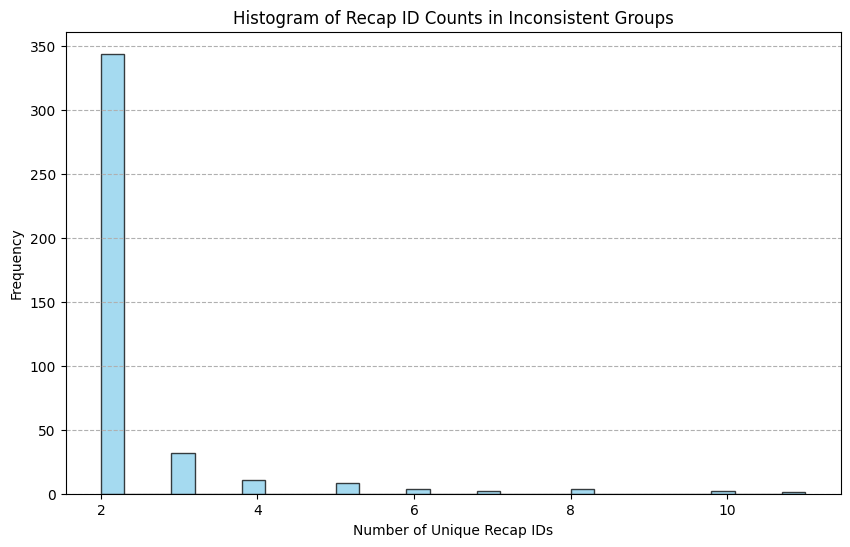

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'inconsistent_groups' is the dataframe containing 'recapid_count' as shown in the screenshot

# Step 1: Plot histogram of 'recapid_count' using matplotlib
plt.figure(figsize=(10, 6))
plt.hist(inconsistent_groups['recapid_count'], bins=30, alpha=0.75, edgecolor='black', color='skyblue')
plt.xlabel('Number of Unique Recap IDs')
plt.ylabel('Frequency')
plt.title('Histogram of Recap ID Counts in Inconsistent Groups')
plt.grid(axis='y', linestyle='--')
plt.show()

# # Alternatively, using seaborn for a more stylized version
# plt.figure(figsize=(10, 6))
# sns.histplot(inconsistent_groups['recapid_count'], bins=30, kde=True, color='skyblue')
# plt.xlabel('Number of Unique Recap IDs')
# plt.ylabel('Frequency')
# plt.title('Histogram of Recap ID Counts in Inconsistent Groups')
# plt.grid(axis='y', linestyle='--')
# plt.show()

In [ ]:
grouped = trading_data.groupby(['parentcorrelationorderid', 'syntheticcontractidentifier']).size().reset_index(name='count')

# Step 2: Display the grouped DataFrame with the count
print(grouped)

trading_data_with_count = trading_data.merge(grouped, on=['parentcorrelationorderid', 'syntheticcontractidentifier'], how='left')

# Display the original DataFrame with the new 'count' column
print(trading_data_with_count.head())

       parentcorrelationorderid syntheticcontractidentifier  count
0                     515428357      SC10080508280341645031     70
1                     515436460      SC10080509113735345304     84
2                     515437257      SC10080510574924145304     86
3                     515437499      SC10080511303334745031     69
4                     515437907      SC10080510574924145304     59
...                         ...                         ...    ...
54187                7035085122      SC08051123055341811100     45
54188                7035086502      SC10080822424281245071     82
54189                7035086854      SC08051123055341811100      4
54190                7035088000      SC08110308292884511132     25
54191                7035088007      SC08101305423184011126     19

[54192 rows x 3 columns]
  trade_date           executiontime brokerexecutiontime  \
0 2024-09-16 2024-09-13 07:15:38.351                 NaT   
1 2024-09-16 2024-09-13 07:15:38.360              

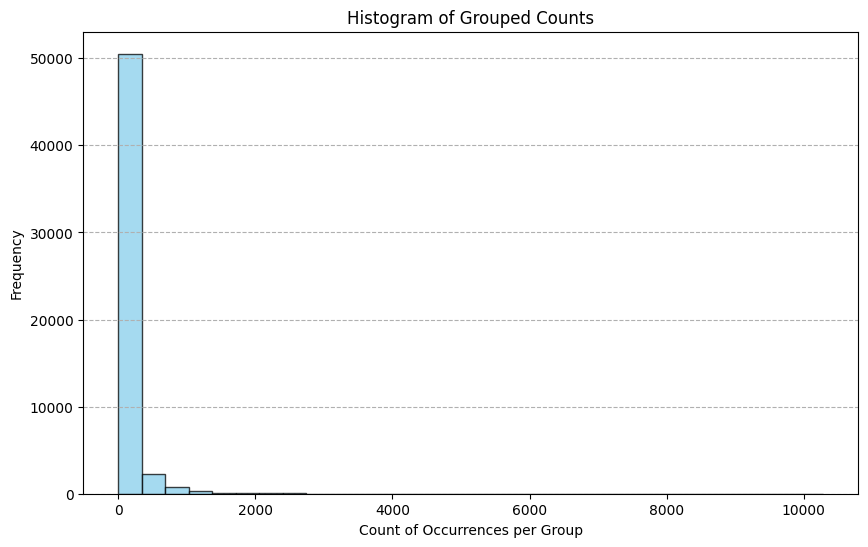

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'grouped' is the dataframe containing the 'count' column after grouping
# Step 1: Plot the histogram using matplotlib
plt.figure(figsize=(10, 6))
plt.hist(grouped['count'], bins=30, alpha=0.75, edgecolor='black', color='skyblue')
plt.xlabel('Count of Occurrences per Group')
plt.ylabel('Frequency')
plt.title('Histogram of Grouped Counts')
plt.grid(axis='y', linestyle='--')
plt.show()


In [ ]:
len(trading_data)

5923559

In [ ]:
len(trading_data['parentcorrelationorderid'].unique())

67358

In [ ]:
import pandas as pd

# Columns include: ['parentcorrelationorderid', 'syntheticcontractidentifier', 'recapid']

# Group by 'parentcorrelationorderid' and 'syntheticcontractidentifier'
# multi_leg_groups = trading_data.groupby(['parentcorrelationorderid', 'syntheticcontractidentifier'])
multi_leg_groups = trading_data.groupby(['syntheticcontractidentifier'])
# Count the number of unique 'recapid' in each group to determine the number of legs
multi_leg_counts = multi_leg_groups['recapid'].nunique().reset_index(name='num_legs')

# Filter to keep only the groups that have more than 1 leg (multi-leg trades)
multi_leg_counts_filtered = multi_leg_counts[multi_leg_counts['num_legs'] > 1]

print("Multi-leg Trades and Number of Legs:")
print(multi_leg_counts_filtered)

Multi-leg Trades and Number of Legs:
     syntheticcontractidentifier  num_legs
0            SC03102014441411104        48
1            SC03102015281111105        16
2            SC03102423462511105        25
3            SC03102523142511105        27
4            SC03102523152211117       230
...                          ...       ...
6037      SC10103113425458045196         2
6040      SC10103114182423446665         6
6043      SC10103114473678946044         2
6045      SC10103115135202147361         2
6060      SC10103120133737646194         2

[3413 rows x 2 columns]


In [ ]:
pd.DataFrame(multi_leg_groups)

,0,1
0,"(515428357, SC10080508280341645031)",trade_date executiontime bro...
1,"(515436460, SC10080509113735345304)",trade_date executiontime bro...
2,"(515437257, SC10080510574924145304)",trade_date executiontime bro...
3,"(515437499, SC10080511303334745031)",trade_date executiontime bro...
4,"(515437907, SC10080510574924145304)",trade_date executiontime bro...
...,...,...
54187,"(7035085122, SC08051123055341811100)",trade_date executiontime ...
54188,"(7035086502, SC10080822424281245071)",trade_date executiontime ...
54189,"(7035086854, SC08051123055341811100)",trade_date executiontime ...
54190,"(7035088000, SC08110308292884511132)",trade_date executiontime ...


In [ ]:
len(multi_leg_groups)

67370

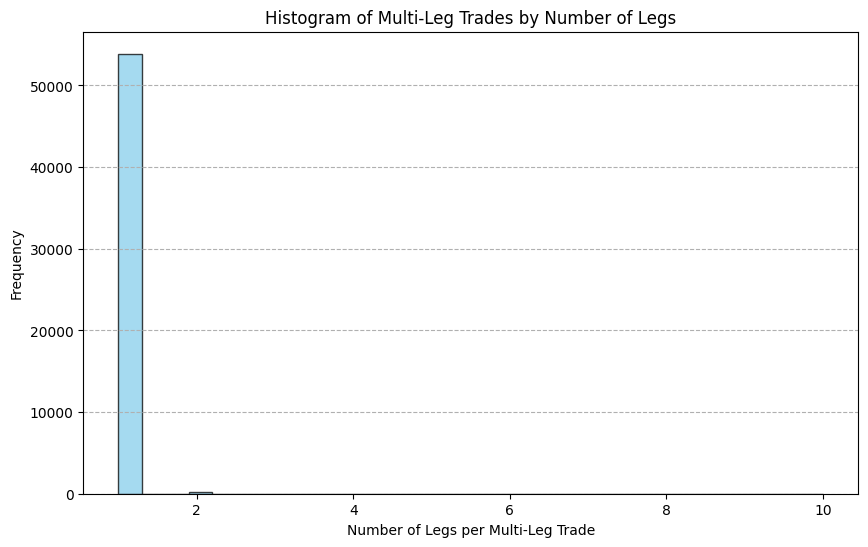

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Plot the histogram using matplotlib
plt.figure(figsize=(10, 6))
plt.hist(multi_leg_counts_filtered['num_legs'], bins=30, alpha=0.75, edgecolor='black', color='skyblue')
plt.xlabel('Number of Legs per Multi-Leg Trade')
plt.ylabel('Frequency')
plt.title('Histogram of Multi-Leg Trades by Number of Legs')
plt.grid(axis='y', linestyle='--')
plt.show()


In [ ]:
trading_data[['recapid', 'orderid', 'instrument', 'parentcorrelationorderid', 'symbol']].head(20)

,recapid,orderid,instrument,parentcorrelationorderid,symbol
0,574483.0,550692610,Z XM ROLL 1.8% FRONTS,7024116908,SFE XMU4-XMZ4
1,574483.0,550692610,Z XM ROLL 1.8% FRONTS,7024116908,SFE XMU4-XMZ4
2,574483.0,550692629,Z XM ROLL 1.8% FRONTS,7024116908,SFE XMU4-XMZ4
3,574483.0,550692629,Z XM ROLL 1.8% FRONTS,7024116908,SFE XMU4-XMZ4
4,574483.0,550692627,Z XM ROLL 1.8% FRONTS,7024116908,SFE XMZ4
5,575216.0,550692662,Z YM ROLL 7.3% FRONTS,550692602,SFE YMZ4
6,575216.0,550692645,Z YM ROLL 7.3% FRONTS,550692602,SFE YMU4-YMZ4
7,575216.0,550692645,Z YM ROLL 7.3% FRONTS,550692602,SFE YMU4-YMZ4
8,575216.0,550692779,Z YM ROLL 7.3% FRONTS,550692602,SFE YMZ4
9,575216.0,550692779,Z YM ROLL 7.3% FRONTS,550692602,SFE YMZ4


In [ ]:
trading_data['instrument']

,instrument
0,Z XM ROLL 1.8% FRONTS
1,Z XM ROLL 1.8% FRONTS
2,Z XM ROLL 1.8% FRONTS
3,Z XM ROLL 1.8% FRONTS
4,Z XM ROLL 1.8% FRONTS
...,...
5923554,CT5-TYZ4-CT10 (TYFLY) (Y)
5923555,CT5-TYZ4-CT10 (TYFLY) (Y)
5923556,CT5-TYZ4-CT10 (TYFLY) (Y)
5923557,CT5-TYZ4-CT10 (TYFLY) (Y)


In [ ]:
trading_data[['syntheticcontractidentifier','syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition']]

,syntheticcontractidentifier,syntheticpricemode,syntheticticksize,syntheticcontractdefinition
0,SC10091306372236346472,P,0.00015,"SFE XMU4-XMZ4,1,1.018,-1;SFE XMZ4,0.017682,0.0..."
1,SC10091306372236346472,P,0.00015,"SFE XMU4-XMZ4,1,1.018,-1;SFE XMZ4,0.017682,0.0..."
2,SC10091306372236346472,P,0.00015,"SFE XMU4-XMZ4,1,1.018,-1;SFE XMZ4,0.017682,0.0..."
3,SC10091306372236346472,P,0.00015,"SFE XMU4-XMZ4,1,1.018,-1;SFE XMZ4,0.017682,0.0..."
4,SC10091306372236346472,P,0.00015,"SFE XMU4-XMZ4,1,1.018,-1;SFE XMZ4,0.017682,0.0..."
...,...,...,...,...
5923554,SC10092522361807645197,Y,0.01000,"CBOT TYZ4,1,1,-2;UST 5_YEAR,-0.0737,-0.737,1;U..."
5923555,SC10092522361807645197,Y,0.01000,"CBOT TYZ4,1,1,-2;UST 5_YEAR,-0.0737,-0.737,1;U..."
5923556,SC10092522361807645197,Y,0.01000,"CBOT TYZ4,1,1,-2;UST 5_YEAR,-0.0737,-0.737,1;U..."
5923557,SC10092522361807645197,Y,0.01000,"CBOT TYZ4,1,1,-2;UST 5_YEAR,-0.0737,-0.737,1;U..."


In [ ]:
bond_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']
regular_bonds = trading_data[trading_data['symbol'].isin(bond_symbols)]
regular_bonds[['syntheticpricemode', 'price']].head(1000)

,syntheticpricemode,price
79861,None,104.859375
79862,None,104.859375
79863,None,104.859375
79864,None,104.859375
79865,None,100.984375
...,...,...
80856,Y,101.119141
80857,Y,101.914062
80858,Y,101.914062
80859,P,99.884766


In [ ]:
regular_bonds[['syntheticpricemode', 'price']].tail(30)

,syntheticpricemode,price
5923529,Y,99.250000
5923530,Y,98.630859
5923531,Y,99.250000
5923532,Y,99.250000
5923533,Y,98.630859
5923534,Y,98.630859
5923535,Y,99.250000
5923536,Y,99.250000
5923537,Y,98.623047
5923538,Y,98.730469


In [ ]:
# Check if there is any occurrence of 'syntheticpricemode' equal to 'P'
has_synthetic_price_mode_p = (regular_bonds['syntheticpricemode'] == 'P').any()

if has_synthetic_price_mode_p:
    print("There are occurrences where 'syntheticpricemode' is 'P'.")
else:
    print("There are no occurrences where 'syntheticpricemode' is 'P'.")

There are occurrences where 'syntheticpricemode' is 'P'.


In [ ]:
# Filter rows where 'syntheticpricemode' is 'P'
synthetic_p_rows = regular_bonds[regular_bonds['syntheticpricemode'] == 'P']

# Count the number of occurrences
count_p = len(synthetic_p_rows)

# Print the number of occurrences
print(f"Number of occurrences where 'syntheticpricemode' is 'P': {count_p}")

Number of occurrences where 'syntheticpricemode' is 'P': 406401


In [ ]:
len(trading_data)

5923559

In [ ]:
import pandas as pd

# Assuming 'trading_data' is already loaded and contains relevant columns
# Step 1: Filter out rows where 'syntheticcontractidentifier' is not null (which indicates a synthetic strategy)
synthetic_trades = trading_data[trading_data['syntheticcontractidentifier'].notna()]

# Step 2: Group by 'syntheticcontractidentifier' to identify unique synthetic strategies
grouped_synthetic_trades = synthetic_trades.groupby('syntheticcontractidentifier')

# Step 3: Create a DataFrame to store multi-leg trade information
multi_leg_trade_data = []

# Step 4: Loop through the grouped synthetic trades to check the 'syntheticcontractdefinition'
for identifier, group in grouped_synthetic_trades:
    # Check if there are multiple instruments in 'syntheticcontractdefinition'
    if group['syntheticcontractdefinition'].str.contains(',', regex=False).any():
        multi_leg_trade_data.append(group)

# Step 5: Combine multi-leg trade groups into a DataFrame
multi_leg_trades = pd.concat(multi_leg_trade_data)

# Display some information on the multi-leg trades
print(f"Total number of multi-leg trades identified: {multi_leg_trades['orderid'].nunique()}")
print(multi_leg_trades[['syntheticcontractidentifier', 'syntheticcontractdefinition']].head())

Total number of multi-leg trades identified: 3196784
        syntheticcontractidentifier  \
1042826         SC03102014441411104   
1042827         SC03102014441411104   
1042828         SC03102014441411104   
1042829         SC03102014441411104   
1042830         SC03102014441411104   

                             syntheticcontractdefinition  
1042826  UST 7_YEAR,1,1,-1;UST 10_YEAR,-0.738,-0.738,1:0  
1042827  UST 7_YEAR,1,1,-1;UST 10_YEAR,-0.738,-0.738,1:0  
1042828  UST 7_YEAR,1,1,-1;UST 10_YEAR,-0.738,-0.738,1:0  
1042829  UST 7_YEAR,1,1,-1;UST 10_YEAR,-0.738,-0.738,1:0  
1042830  UST 7_YEAR,1,1,-1;UST 10_YEAR,-0.738,-0.738,1:0  


In [ ]:
# Count the number of unique trades using 'orderid' or 'executionid'
unique_trades_count = trading_data['orderid'].nunique()

# Identify multi-leg trades by filtering rows where synthetic contract columns are non-null
# multi_leg_trades = trading_data[trading_data['syntheticcontractidentifier'].notna() |
#                                 trading_data['syntheticcontractdefinition'].notna() |
#                                 trading_data['syntheticpricemode'].notna() |
#                                 trading_data['syntheticticksize'].notna()]
multi_leg_trades = trading_data[
    trading_data['syntheticcontractidentifier'].notna() |
    trading_data['syntheticcontractdefinition'].notna()
]

multi_leg_trades_count = multi_leg_trades['orderid'].nunique()

print(f"Total unique trades: {unique_trades_count}")
print(f"Total multi-leg trades: {multi_leg_trades_count}")

Total unique trades: 3292512
Total multi-leg trades: 3196784


In [ ]:
# Group by 'client' and find the unique categories of multi-leg trades
multi_leg_categories = multi_leg_trades.groupby('client')['syntheticcontractdefinition'].unique().reset_index()

print("Unique categories of multi-leg trades by each client:")
print(multi_leg_categories)

Unique categories of multi-leg trades by each client:
       client                        syntheticcontractdefinition
0    AAJXALQL  [UST 20_YEAR,1,1,-1;UST 30_YEAR,-0.799,-0.799,...
1    AAWKGZRZ  [UST 10_YEAR,1,1,-1;CME SFR:AB 02Y Z4,-4.17,-8...
2    AEJUWPCO  [CBOT TUZ4,1,1,-1;UST 2_YEAR,-0.2194,-1.097,1:...
3    AEKVVLZJ  [UST 5_YEAR,1,1,-2;UST 3_YEAR,-0.816,-0.816,1;...
4    AIIQCKAD  [EUREX DUZ4,1,1,-1;EUREX BTSZ4,-0.841,-0.841,1...
..        ...                                                ...
644  ZSQXEWJW  [IFLL G U4-G Z4,0.8223684,1,-1;IFLL G U4,0.177...
645  ZSUVNLCR  [UST 20_YEAR,1,1,-2;CBOT USZ4,-4.8,-0.48,1;CBO...
646  ZSVZENND  [UST 20_YEAR,1,1,-2;CBOT USZ4,-4.8,-0.48,1;CBO...
647  ZXYLWCIQ  [CBOT TUU4-TUZ4,0.88574,1,-1;CBOT TUU4,0.11426...
648  ZYWFMZVS  [CBOT FVZ4,1,1,-1;UST 5_YEAR,-0.0983,-0.983,1:...

[649 rows x 2 columns]


In [ ]:
multi_leg_categories

,client,syntheticcontractdefinition
0,AAJXALQL,"[UST 20_YEAR,1,1,-1;UST 30_YEAR,-0.799,-0.799,..."
1,AAWKGZRZ,"[UST 10_YEAR,1,1,-1;CME SFR:AB 02Y Z4,-4.17,-8..."
2,AEJUWPCO,"[CBOT TUZ4,1,1,-1;UST 2_YEAR,-0.2194,-1.097,1:..."
3,AEKVVLZJ,"[UST 5_YEAR,1,1,-2;UST 3_YEAR,-0.816,-0.816,1;..."
4,AIIQCKAD,"[EUREX DUZ4,1,1,-1;EUREX BTSZ4,-0.841,-0.841,1..."
...,...,...
644,ZSQXEWJW,"[IFLL G U4-G Z4,0.8223684,1,-1;IFLL G U4,0.177..."
645,ZSUVNLCR,"[UST 20_YEAR,1,1,-2;CBOT USZ4,-4.8,-0.48,1;CBO..."
646,ZSVZENND,"[UST 20_YEAR,1,1,-2;CBOT USZ4,-4.8,-0.48,1;CBO..."
647,ZXYLWCIQ,"[CBOT TUU4-TUZ4,0.88574,1,-1;CBOT TUU4,0.11426..."


In [ ]:
# Step 1: Count the number of multi-leg trades for each client
multi_leg_trade_counts = multi_leg_trades.groupby('client')['syntheticcontractidentifier'].count().reset_index()

# Step 2: Rename the columns for better clarity
multi_leg_trade_counts.columns = ['client', 'multi_leg_trade_count']

# Step 3: Display the result
print("Number of multi-leg trades by each client:")
print(multi_leg_trade_counts)

Number of multi-leg trades by each client:
       client  multi_leg_trade_count
0    AAJXALQL                  31149
1    AAWKGZRZ                  67178
2    AEJUWPCO                   4065
3    AEKVVLZJ                  18970
4    AIIQCKAD                   1182
..        ...                    ...
644  ZSQXEWJW                    811
645  ZSUVNLCR                  56554
646  ZSVZENND                   7383
647  ZXYLWCIQ                    145
648  ZYWFMZVS                    405

[649 rows x 2 columns]


In [ ]:
import pandas as pd

# Assuming 'multi_leg_trades' dataframe is already loaded and contains the columns 'syntheticcontractdefinition', 'trade_date', 'quantity'
# Ensure that 'trade_date' is in datetime format
multi_leg_trades['trade_date'] = pd.to_datetime(multi_leg_trades['trade_date'])

# Step 1: Group by 'syntheticcontractdefinition' and 'trade_date' to get daily total volume for each strategy
daily_volume = multi_leg_trades.groupby(['syntheticcontractdefinition', 'trade_date'])['quantity'].sum().reset_index()

# Step 2: Calculate the Average Daily Volume (ADV) for each multi-leg strategy
adv_per_strategy = daily_volume.groupby('syntheticcontractdefinition')['quantity'].mean().reset_index()
adv_per_strategy.columns = ['syntheticcontractdefinition', 'ADV']

# Step 3: Display the ADV for each strategy
print("Average Daily Volume (ADV) for each multi-leg strategy:")
print(adv_per_strategy)


<ipython-input-33-82beed0970d8>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi_leg_trades['trade_date'] = pd.to_datetime(multi_leg_trades['trade_date'])


Average Daily Volume (ADV) for each multi-leg strategy:
                            syntheticcontractdefinition    ADV
0     CBOT 3YU4,1,1,-1;CBOT TUU4,-0.891,-0.891,1;CBO...  708.5
1        CBOT 3YU4,1,1,-1;UST 3_YEAR,-0.2108,-1.054,1:0  199.0
2        CBOT 3YU4,1,1,-1;UST 3_YEAR,-0.2144,-1.072,1:0  996.0
3     CBOT 3YZ4,1,1,-1;CME SFR:AB 03Y Z4,-0.202,-3.0...  449.5
4       CBOT 3YZ4,1,1,-1;UST 10_YEAR,-0.0726,-0.363,1:0  282.0
...                                                 ...    ...
6056  UST o5_YEAR.CT5B,1,1,-1;UST 30_YEAR,-0.258,-0....   55.0
6057  UST o5_YEAR.CT5B,1,1,-2;UST 2_YEAR,-1.176,-1.1...   13.5
6058  UST o7_YEAR.CT7B,1,32,-1;CBOT TYZ4,-8.804,-28....   20.0
6059  UST o7_YEAR.CT7B,1,32,-1;CBOT TYZ4,-9.069,-29....  121.0
6060  UST oo7_YEAR.CT7C,1,32,-1;CBOT TYZ4,-9.069,-29...   40.0

[6061 rows x 2 columns]


In [ ]:
# Count the number of unique LPs in the dataset
unique_lps_count = trading_data['exchange_lp'].nunique()

print(f"Total unique LPs in the dataset: {unique_lps_count}")

Total unique LPs in the dataset: 22


In [ ]:
# Count the number of hedge trades versus regular trades
hedge_trades = trading_data[trading_data['quote_or_hedge'] == 'Hedge']
hedge_trades_count = hedge_trades['orderid'].nunique()
regular_trades_count = unique_trades_count - hedge_trades_count

print(f"Number of hedge trades: {hedge_trades_count}")
print(f"Number of regular trades: {regular_trades_count}")

Number of hedge trades: 938107
Number of regular trades: 2354405


In [ ]:
import pandas as pd

# Assuming the trading_data and multi_leg_trades dataframes are already loaded

# Step 1: Create a new column for the month and year in both dataframes
trading_data['trade_date'] = pd.to_datetime(trading_data['trade_date'])  # Convert to datetime if not done
trading_data['month_year'] = trading_data['trade_date'].dt.to_period('M')

multi_leg_trades['trade_date'] = pd.to_datetime(multi_leg_trades['trade_date'])  # Convert to datetime if not done
multi_leg_trades['month_year'] = multi_leg_trades['trade_date'].dt.to_period('M')

# Step 2: Calculate monthly unique trades for 'trading_data'
monthly_unique_trades = trading_data.groupby('month_year')['orderid'].nunique().reset_index()
monthly_unique_trades.columns = ['month_year', 'unique_trades']

# Step 3: Calculate monthly multi-leg trades for 'multi_leg_trades'
monthly_multi_leg_trades = multi_leg_trades.groupby('month_year')['orderid'].nunique().reset_index()
monthly_multi_leg_trades.columns = ['month_year', 'multi_leg_trades']

# Display the results
print("Monthly breakdown of unique trades:")
print(monthly_unique_trades)

print("Monthly breakdown of multi-leg trades:")
print(monthly_multi_leg_trades)

<ipython-input-80-919df4e66271>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi_leg_trades['trade_date'] = pd.to_datetime(multi_leg_trades['trade_date'])  # Convert to datetime if not done
<ipython-input-80-919df4e66271>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi_leg_trades['month_year'] = multi_leg_trades['trade_date'].dt.to_period('M')


Monthly breakdown of unique trades:
  month_year  unique_trades
0    2024-08        1128028
1    2024-09        1073161
2    2024-10        1091324
Monthly breakdown of multi-leg trades:
  month_year  multi_leg_trades
0    2024-08           1102089
1    2024-09           1039799
2    2024-10           1054896


In [ ]:
trading_data['exchange_lp']

,exchange_lp
0,None
1,None
2,None
3,None
4,None
...,...
5923554,SBUWHHFR
5923555,SBUWHHFR
5923556,OQFTYCMP
5923557,OQFTYCMP


In [ ]:
trading_data['parentcorrelationorderid']

,parentcorrelationorderid
0,7024116908
1,7024116908
2,7024116908
3,7024116908
4,7024116908
...,...
5923554,7029291632
5923555,7029291632
5923556,7029291632
5923557,7029291632


In [ ]:
trading_data['order_source']

,order_source
0,Other-Core
1,Other-Core
2,Other-Core
3,Other-Core
4,Other-Core
...,...
5923554,Other-Core
5923555,Other-Core
5923556,Other-Core
5923557,Other-Core


In [ ]:
trading_data['instrument'].head(30)

,instrument
0,Z XM ROLL 1.8% FRONTS
1,Z XM ROLL 1.8% FRONTS
2,Z XM ROLL 1.8% FRONTS
3,Z XM ROLL 1.8% FRONTS
4,Z XM ROLL 1.8% FRONTS
5,Z YM ROLL 7.3% FRONTS
6,Z YM ROLL 7.3% FRONTS
7,Z YM ROLL 7.3% FRONTS
8,Z YM ROLL 7.3% FRONTS
9,Z YM ROLL 7.3% FRONTS


In [ ]:
trading_data['is_aggressive'].unique()

array([nan,  0.,  1.])

In [ ]:
trading_data['side'].unique()

array(['B', 'S'], dtype=object)

In [ ]:
trading_data['symbol'].unique()

array(['SFE XMU4-XMZ4', 'SFE XMZ4', 'SFE YMZ4', 'SFE YMU4-YMZ4',
       'CBOT TYZ4', 'CBOT WNZ4', 'CBOT TUZ4', 'CME SFRZ5', 'CBOT FFV4',
       'EUREX UBZ4', 'EUREX OEZ4', 'CBOT FFN5-FFQ5', 'EUREX DUZ4',
       'IFLL ERZ4', 'ME CVZ4', 'ME CNZ4', 'ME CORH5', 'ME CORZ4',
       'ME CORZ5', 'ME CORU5', 'ME CORH6', 'ME CORM5', 'ME XQZ4',
       'CME SFRH5', 'CME SERV4-FFV4', 'CBOT FFX4', 'CBOT FFU4',
       'CBOT USZ4', 'CBOT UXYZ4', 'CBOT FVZ4', 'ME CORM6',
       'CME SFR:AB 02Y Z4', 'CME SFRZ4', 'CME SERU4', 'EUREX IKZ4',
       'EUREX RXZ4', 'CME SERV4', 'CME SERX4', 'IFLL ERU5', 'EUREX OATZ4',
       'EUREX BTSZ4', 'CME SFR:BF M6-U6-Z6', 'CME SERF5-FFF5',
       'CME SFRZ4-SFRZ5', 'CME SFR:AB 01Y Z4', 'CME SFR:AB 01Y Z7',
       'CME SFR:AB 01Y Z6', 'CME SFR:AB 01Y Z5', 'CME SFRU4', 'CME SFRZ8',
       'CME SFRH9', 'CME SFRM9', 'CME SFR:AB 05Y Z4', 'CME SFR:AB 03Y Z4',
       'CME SFRM5', 'CME SFRU5', 'CME SFRU6', 'CME SFRM6', 'IFLL G Z4',
       'CME SFRH8', 'CME SFRZ6', 'CME SFRH6',

# how many trades for each symbol (ADV)

In [ ]:
import pandas as pd

trading_data['timestamp'] = pd.to_datetime(trading_data['timestamp'])

# Step 1: Extract the date from the timestamp (without time part)
trading_data['date'] = trading_data['timestamp'].dt.date

# Step 2: Group by 'symbol' and 'date' and calculate the total volume (quantity) for each day
daily_volume = trading_data.groupby(['symbol', 'date'])['quantity'].sum().reset_index()

# Step 3: Calculate the average daily volume per symbol
avg_daily_volume = daily_volume.groupby('symbol')['quantity'].mean().reset_index()

print(avg_daily_volume)

            symbol     quantity
0          10 Year  7446.895522
1       10 Year O1   112.454545
2           2 Year  6267.666667
3          20 Year  1267.061538
4       20 Year O1    22.000000
..             ...          ...
552  SFE YMU4-YMZ4  7456.000000
553   SFE YMU4XMU4  1095.384615
554       SFE YMZ4   225.142857
555   SFE YMZ4XMZ4  1021.533333
556       SGX XUV4   200.000000

[557 rows x 2 columns]


In [ ]:
ranked_volume = avg_daily_volume.sort_values(by='quantity', ascending=False).reset_index(drop=True)

# Display the ranked volume
print(ranked_volume)

                     symbol      quantity
0            CBOT FVU4-FVZ4  70548.562500
1            CBOT TUU4-TUZ4  61117.038462
2            CBOT TYU4-TYZ4  46063.818182
3           EUREX OEU4-OEZ4  44618.714286
4                 CBOT FVU4  28104.708333
..                      ...           ...
552  IFLL ER: FFLY U5-H6-U6      4.000000
553              NYMEX CLZ5      3.600000
554         CME SERF5-SERK5      3.000000
555          CME SERN5-FFN5      2.000000
556               OSE JOAH5      1.000000

[557 rows x 2 columns]


In [ ]:
ranked_volume.head(50)

,symbol,quantity
0,CBOT FVU4-FVZ4,70548.562500
1,CBOT TUU4-TUZ4,61117.038462
2,CBOT TYU4-TYZ4,46063.818182
3,EUREX OEU4-OEZ4,44618.714286
4,CBOT FVU4,28104.708333
5,CBOT FVZ4,26208.929825
6,CBOT TUU4,21888.130435
7,CBOT UXYU4-UXYZ4,21407.647059
8,CBOT TYZ4,18938.290323
9,EUREX DUU4-DUZ4,18741.647059


In [ ]:
ranked_volume.tail(30)

,symbol,quantity
527,IFLL SFIU7-SFIZ7,12.000000
528,IFLL SFIZ7-SFIH8,12.000000
529,IFLL SFIM7-SFIZ7,12.000000
530,IFLL SFIU7-SFIH8,12.000000
531,CME SERM5-FFM5,11.000000
532,IFLL TKYM6-ERM6,11.000000
533,IFLL ERU9,10.750000
534,IFLL SFIU5-SFIU6,10.666667
535,IFLL ERH7-ERM7,10.000000
536,NYMEX NGG5,10.000000


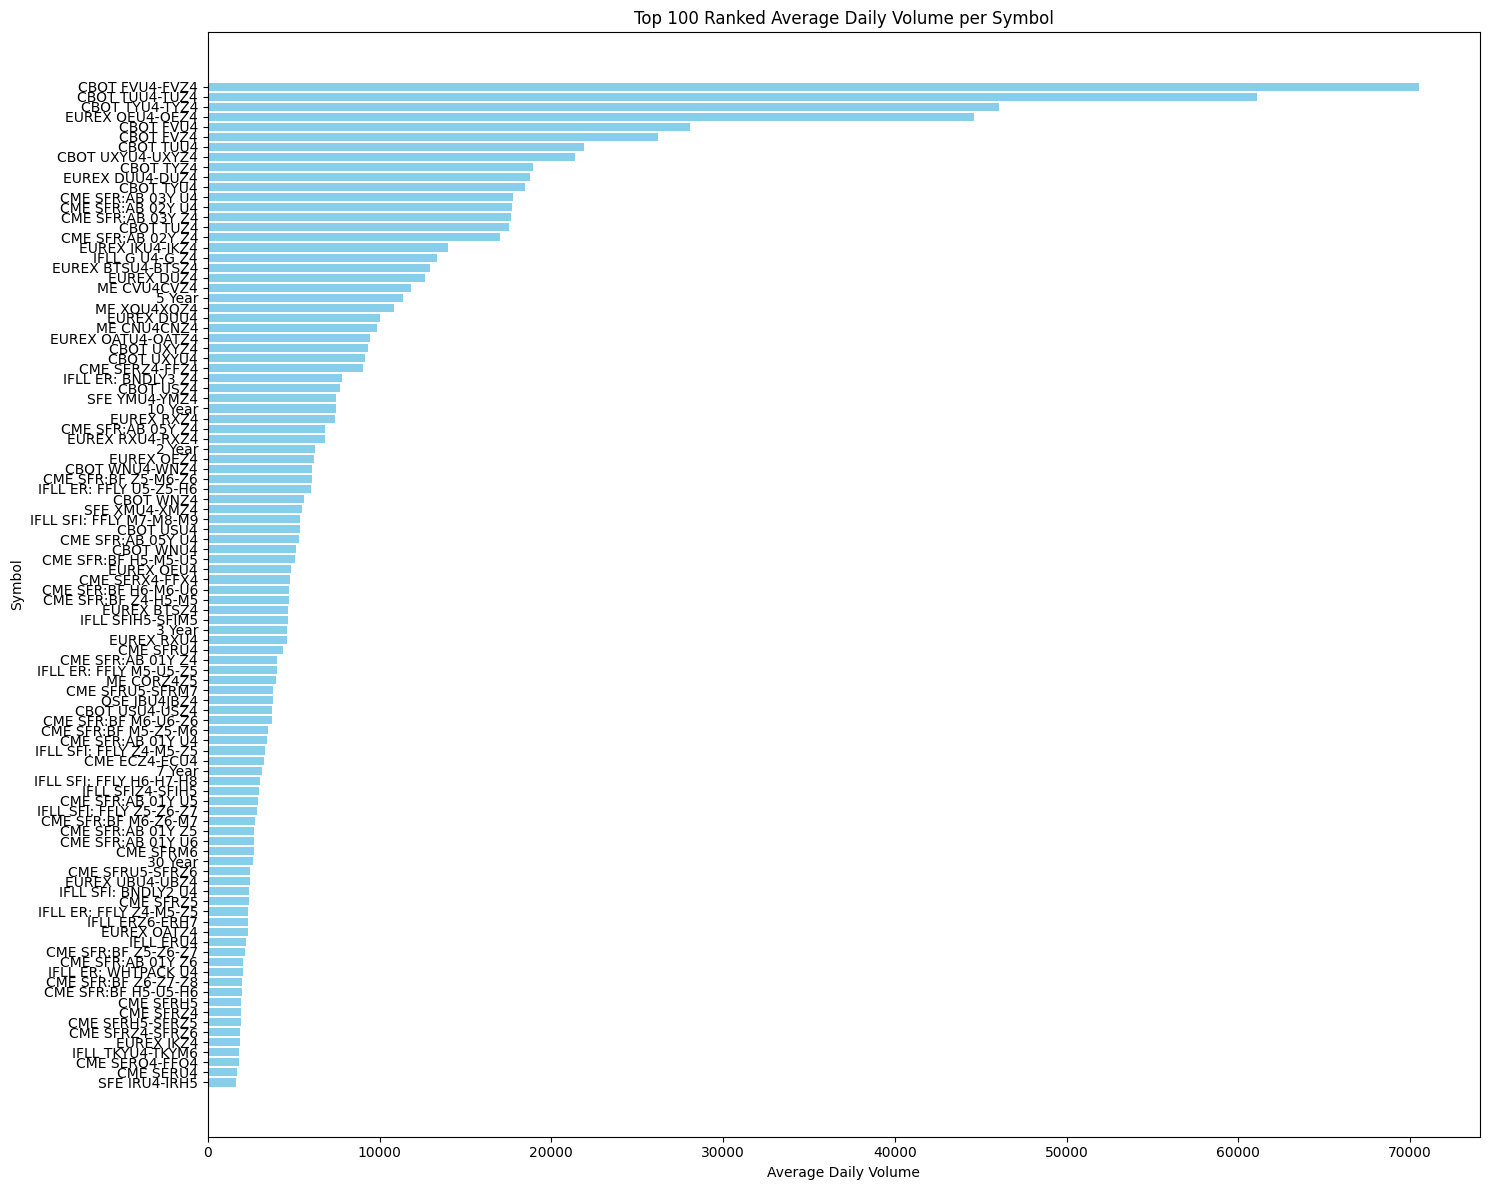

In [ ]:
import matplotlib.pyplot as plt

# Step 1: Limit to the top 100 symbols
top_100_volume = ranked_volume.head(100)

# Step 2: Define the data for plotting
symbols = top_100_volume['symbol']
quantities = top_100_volume['quantity']

# Step 3: Create the plot
plt.figure(figsize=(15, 12))
plt.barh(symbols, quantities, color='skyblue')  # Horizontal bar chart for ranking

# Step 4: Customize the plot
plt.xlabel('Average Daily Volume')
plt.ylabel('Symbol')
plt.title('Top 100 Ranked Average Daily Volume per Symbol')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest volume at the top
plt.tight_layout()

# Step 5: Display the plot
plt.show()

# look the difference between '10 Year'and '10 Year O1'

In [ ]:
import pandas as pd

bond_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']

# Regular bonds (without '01' suffix)
regular_bonds = trading_data[trading_data['symbol'].isin(bond_symbols)]

# Bonds with '01' suffix (containing '01' in the name)
bonds_01 = trading_data[trading_data['symbol'].str.contains(r' \d{1,2} 01$')]

In [ ]:
regular_bonds

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,timestamp,build_id,build_name,hide_duration,pop_ticks,label,order_flow,time_rounded,time_diff,date
79861,2024-09-16,2024-09-16 06:32:33.514,2024-09-16 06:32:33.512,2024-09-16 02:32:33.512,575316.0,7024412350,7024412350,696312820.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:32:33.513999872,NaN,None,NaN,None,r8fin_trades,-1.0,2024-09-16 06:32:30,-52006.454,2024-09-16
79862,2024-09-16,2024-09-16 06:32:57.002,2024-09-16 06:32:57.002,2024-09-16 02:32:57.002,575316.0,7024412350,7024412350,696312821.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:32:57.002000128,NaN,None,NaN,None,r8fin_trades,-1.0,2024-09-16 06:32:50,23.488,2024-09-16
79863,2024-09-16,2024-09-16 06:33:01.095,2024-09-16 06:33:01.093,2024-09-16 02:33:01.093,575316.0,7024412350,7024412350,696312822.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:33:01.095000064,NaN,None,NaN,None,r8fin_trades,-1.0,2024-09-16 06:33:00,4.093,2024-09-16
79864,2024-09-16,2024-09-16 06:33:01.093,2024-09-16 06:33:01.091,2024-09-16 02:33:01.091,575316.0,7024412350,7024412350,696312823.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:33:01.092999936,NaN,None,NaN,None,r8fin_trades,-1.0,2024-09-16 06:33:00,-0.002,2024-09-16
79865,2024-09-16,2024-09-16 06:45:16.811,2024-09-16 06:45:16.809,2024-09-16 02:45:16.809,575318.0,7024412361,7024412361,696312881.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:45:16.811000064,NaN,None,NaN,None,r8fin_trades,-2.0,2024-09-16 06:45:10,735.718,2024-09-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5923554,2024-10-04,2024-10-04 20:59:06.135,2024-10-04 20:59:06.128,2024-10-04 16:59:06.128,590551.0,7029292600,7029291632,699617037.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.135000064,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,-1.0,2024-10-04 20:59:00,0.000,2024-10-04
5923555,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.130,2024-10-04 16:59:06.130,590551.0,7029292601,7029291632,699617036.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.136000000,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,-1.0,2024-10-04 20:59:00,0.001,2024-10-04
5923556,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.131,2024-10-04 16:59:06.131,590551.0,7029292601,7029291632,699617034.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.136000000,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,-3.0,2024-10-04 20:59:00,0.000,2024-10-04
5923557,2024-10-04,2024-10-04 20:59:06.138,2024-10-04 20:59:06.132,2024-10-04 16:59:06.132,590551.0,7029292602,7029291632,699617033.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.138000128,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,-1.0,2024-10-04 20:59:00,0.002,2024-10-04


In [ ]:
trading_data['quote_or_hedge'].unique()

array(['Other', 'Hedge', 'Quote'], dtype=object)

In [ ]:
trading_data['quantity']

,quantity
0,171.0
1,171.0
2,65.0
3,65.0
4,4.0
...,...
5923554,1.0
5923555,1.0
5923556,3.0
5923557,1.0


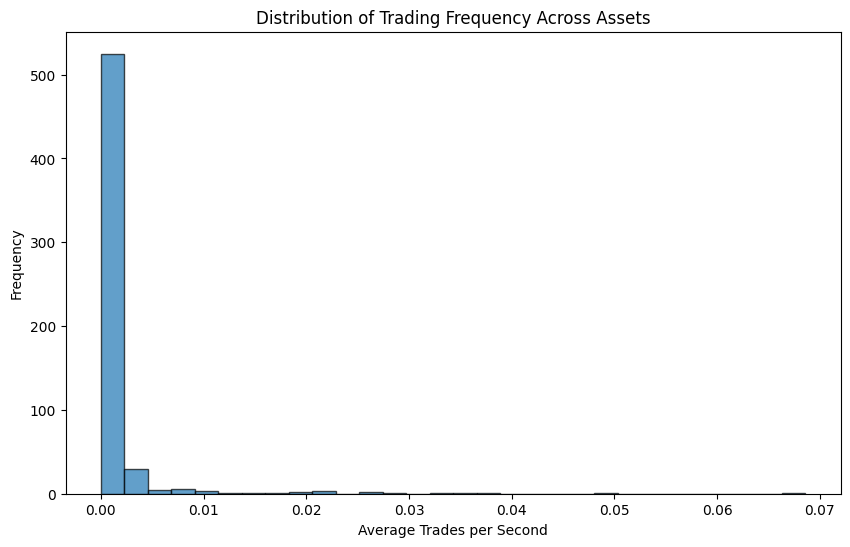

count    5.850000e+02
mean     1.296745e-03
std      5.254958e-03
min      1.280642e-07
25%      6.915468e-06
50%      3.739475e-05
75%      3.310460e-04
max      6.859107e-02
dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

trading_data['timestamp'] = pd.to_datetime(trading_data['timestamp'])


trading_data['time_diff'] = trading_data['timestamp'].diff().dt.total_seconds()

# Calculate the number of trades per second
# We will assume that trades happen on the same second, so 1 trade per row in a second
# The frequency of trades per second for each asset can be calculated by dividing the number of trades by the total duration in seconds
frequency = trading_data.groupby('symbol').size() / (trading_data['timestamp'].max() - trading_data['timestamp'].min()).total_seconds()


plt.figure(figsize=(10, 6))
plt.hist(frequency, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Average Trades per Second')
plt.ylabel('Frequency')
plt.title('Distribution of Trading Frequency Across Assets')
plt.show()

print(frequency.describe())

In [ ]:
# Calculate the total number of trades per symbol
total_trades = trading_data.groupby('symbol').size()

# Calculate the total market hours (assuming the market opens at 9:30 AM and closes at 4:00 PM)
market_start_time = pd.to_datetime('09:30:00')
market_end_time = pd.to_datetime('16:00:00')
market_duration_seconds = (market_end_time - market_start_time).seconds

min_bin_size_seconds = market_duration_seconds / (total_trades / 20)  # Bin size ensuring at least 10 trades

# Check for the minimum bin size that ensures 10-20 trades
min_bin_size_seconds

,0
symbol,
10 Year,1.207542
10 Year O1,387.096774
2 Year,1.853282
20 Year,6.084164
20 Year O1,4178.571429
...,...
SFE YMU4-YMZ4,1368.421053
SFE YMU4XMU4,1779.467681
SFE YMZ4,3162.162162


In [ ]:
min_bin_size_seconds.head(20)

,0
symbol,
10 Year,1.207542
10 Year O1,387.096774
2 Year,1.853282
20 Year,6.084164
20 Year O1,4178.571429
3 Year,2.170707
3 Year O1,13764.705882
30 Year,2.643082
30 Year O1,29250.000000


In [ ]:
import pandas as pd

trading_data['timestamp'] = pd.to_datetime(trading_data['timestamp'])

# 'B' for Buy, 'S' for Sell
trading_data['order_flow'] = trading_data['side'].map({'B': 1, 'S': -1}) * trading_data['quantity']

# Round the timestamp to the nearest 10 seconds for grouping
trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')

# Group by the rounded timestamp and sum the order flows for each 10-second interval
order_flow_aggregated = trading_data.groupby('time_rounded')['order_flow'].sum().reset_index()

<ipython-input-8-aeb0510ec5f8>:14: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')


         time_rounded  order_flow
0 2024-08-02 11:56:30       -17.0
1 2024-08-02 12:03:00       -51.0
2 2024-08-02 12:03:30       -81.0
3 2024-08-02 12:03:40       -23.0
4 2024-08-02 12:33:40        15.0


In [ ]:
order_flow_aggregated

,time_rounded,order_flow
0,2024-08-02 11:56:30,-17.0
1,2024-08-02 12:03:00,-51.0
2,2024-08-02 12:03:30,-81.0
3,2024-08-02 12:03:40,-23.0
4,2024-08-02 12:33:40,15.0
...,...,...
229171,2024-10-31 20:59:00,-11.0
229172,2024-10-31 20:59:10,-140.0
229173,2024-10-31 20:59:20,4.0
229174,2024-10-31 20:59:30,-20.0


# bonds dataframe

In [ ]:
symbols_list = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']

selected_data = trading_data[trading_data['symbol'].isin(symbols_list)]

print(selected_data)

        trade_date           executiontime     brokerexecutiontime  \
79861   2024-09-16 2024-09-16 06:32:33.514 2024-09-16 06:32:33.512   
79862   2024-09-16 2024-09-16 06:32:57.002 2024-09-16 06:32:57.002   
79863   2024-09-16 2024-09-16 06:33:01.095 2024-09-16 06:33:01.093   
79864   2024-09-16 2024-09-16 06:33:01.093 2024-09-16 06:33:01.091   
79865   2024-09-16 2024-09-16 06:45:16.811 2024-09-16 06:45:16.809   
...            ...                     ...                     ...   
5923554 2024-10-04 2024-10-04 20:59:06.135 2024-10-04 20:59:06.128   
5923555 2024-10-04 2024-10-04 20:59:06.136 2024-10-04 20:59:06.130   
5923556 2024-10-04 2024-10-04 20:59:06.136 2024-10-04 20:59:06.131   
5923557 2024-10-04 2024-10-04 20:59:06.138 2024-10-04 20:59:06.132   
5923558 2024-10-04 2024-10-04 20:59:23.826 2024-10-04 20:59:23.825   

                   exec_time_et   recapid     orderid  \
79861   2024-09-16 02:32:33.512  575316.0  7024412350   
79862   2024-09-16 02:32:57.002  575316.0  70

# average daily volume

In [ ]:
import pandas as pd

selected_data['timestamp'] = pd.to_datetime(selected_data['timestamp'])

# Step 1: Extract the date from the timestamp (without time part)
selected_data['date'] = selected_data['timestamp'].dt.date

# Step 2: Group by 'symbol' and 'date' and calculate the total volume (quantity) for each day
daily_volume = selected_data.groupby(['symbol', 'date'])['quantity'].sum().reset_index()

# Step 3: Calculate the average daily volume per symbol
avg_daily_volume = daily_volume.groupby('symbol')['quantity'].mean().reset_index()

print(avg_daily_volume)

<ipython-input-4-7642a83330e1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['timestamp'] = pd.to_datetime(selected_data['timestamp'])
<ipython-input-4-7642a83330e1>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['date'] = selected_data['timestamp'].dt.date


    symbol      quantity
0  10 Year   7446.895522
1   2 Year   6267.666667
2  20 Year   1267.061538
3   3 Year   4632.194030
4  30 Year   2635.250000
5   5 Year  11352.328571
6   7 Year   3128.731343


<ipython-input-7-25317b3a9d4a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['timestamp'] = pd.to_datetime(selected_data['timestamp'])
<ipython-input-7-25317b3a9d4a>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['time_diff'] = selected_data['timestamp'].diff().dt.total_seconds()


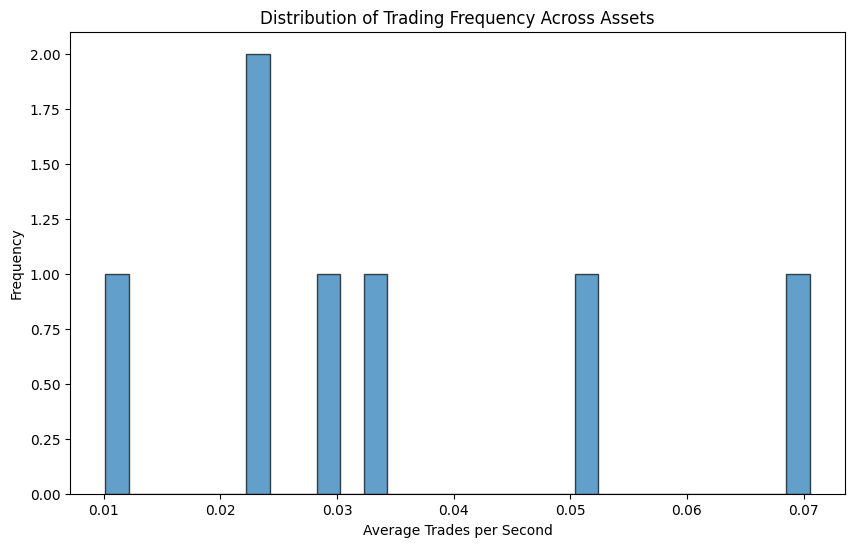

count    7.000000
mean     0.034210
std      0.020274
min      0.010130
25%      0.023058
50%      0.028393
75%      0.042148
max      0.070536
dtype: float64


In [ ]:
import matplotlib.pyplot as plt

selected_data['timestamp'] = pd.to_datetime(selected_data['timestamp'])

selected_data['time_diff'] = selected_data['timestamp'].diff().dt.total_seconds()

# Calculate the number of trades per second

# The frequency of trades per second for each asset can be calculated by dividing the number of trades by the total duration in seconds
frequency = selected_data.groupby('symbol').size() / (selected_data['timestamp'].max() - selected_data['timestamp'].min()).total_seconds()


plt.figure(figsize=(10, 6))
plt.hist(frequency, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Average Trades per Second')
plt.ylabel('Frequency')
plt.title('Distribution of Trading Frequency Across Assets')
plt.show()

print(frequency.describe())

In [ ]:
import pandas as pd

# Assuming 'trading_data' is already loaded and contains relevant columns
# Step 1: Filter out rows where 'syntheticcontractidentifier' is not null (which indicates a synthetic strategy)
synthetic_trades = selected_data[selected_data['syntheticcontractidentifier'].notna()]

# Step 2: Group by 'syntheticcontractidentifier' to identify unique synthetic strategies
grouped_synthetic_trades = synthetic_trades.groupby('syntheticcontractidentifier')

# Step 3: Create a DataFrame to store multi-leg trade information
multi_leg_trade_data = []

# Step 4: Loop through the grouped synthetic trades to check the 'syntheticcontractdefinition'
for identifier, group in grouped_synthetic_trades:
    # Check if there are multiple instruments in 'syntheticcontractdefinition'
    if group['syntheticcontractdefinition'].str.contains(',', regex=False).any():
        multi_leg_trade_data.append(group)

# Step 5: Combine multi-leg trade groups into a DataFrame
multi_leg_trades = pd.concat(multi_leg_trade_data)

# Display some information on the multi-leg trades
print(f"Total number of multi-leg trades identified: {multi_leg_trades['orderid'].nunique()}")
print(multi_leg_trades[['syntheticcontractidentifier', 'syntheticcontractdefinition']].head())


Total number of multi-leg trades identified: 1435009
        syntheticcontractidentifier  \
1042826         SC03102014441411104   
1042827         SC03102014441411104   
1042828         SC03102014441411104   
1042829         SC03102014441411104   
1042830         SC03102014441411104   

                             syntheticcontractdefinition  
1042826  UST 7_YEAR,1,1,-1;UST 10_YEAR,-0.738,-0.738,1:0  
1042827  UST 7_YEAR,1,1,-1;UST 10_YEAR,-0.738,-0.738,1:0  
1042828  UST 7_YEAR,1,1,-1;UST 10_YEAR,-0.738,-0.738,1:0  
1042829  UST 7_YEAR,1,1,-1;UST 10_YEAR,-0.738,-0.738,1:0  
1042830  UST 7_YEAR,1,1,-1;UST 10_YEAR,-0.738,-0.738,1:0  


In [ ]:
# Count the number of unique trades using 'orderid' or 'executionid'
unique_trades_count = selected_data['orderid'].nunique()

multi_leg_trades = selected_data[
    selected_data['syntheticcontractidentifier'].notna() |
    selected_data['syntheticcontractdefinition'].notna()
]

multi_leg_trades_count = multi_leg_trades['orderid'].nunique()

print(f"Total unique trades: {unique_trades_count}")
print(f"Total multi-leg trades: {multi_leg_trades_count}")

Total unique trades: 1438723
Total multi-leg trades: 1435009


In [ ]:
# Count the number of unique LPs in the dataset
unique_lps_count = selected_data['exchange_lp'].nunique()

print(f"Total unique LPs in the dataset: {unique_lps_count}")

Total unique LPs in the dataset: 22


In [ ]:
# Count the number of hedge trades versus regular trades
hedge_trades = selected_data[selected_data['quote_or_hedge'] == 'Hedge']
hedge_trades_count = hedge_trades['orderid'].nunique()
regular_trades_count = unique_trades_count - hedge_trades_count

print(f"Number of hedge trades: {hedge_trades_count}")
print(f"Number of regular trades: {regular_trades_count}")

Number of hedge trades: 630763
Number of regular trades: 807960
